In [1]:
import pandas as pd
training_df = pd.read_parquet("../data/01_raw/train_df.parquet")
testing_df = pd.read_parquet("../data/01_raw/test_df.parquet")

In [2]:
# Training Data 
print(training_df.head())

   Unnamed: 0                              Drug  ClogP     BSEP    Glu  \
0          29  Flupirtine (Kv7 hepatotoxic@400)  3.053  100.000  300.0   
1          30  Flupirtine (Kv7 hepatotoxic@600)  3.053  100.000  300.0   
2          51                        Pranlukast  5.075    2.055  221.7   
3          57    Acetylsalicylic Acid (Aspirin)  1.023  200.000  300.0   
4          58                         Acyclovir -2.422  100.000  300.0   

   Glu_Gal   THLE  HepG2       vDILIConcern   Fsp3  log10cmax  dili_sev  
0      1.0  277.7  300.0  Most-DILI-Concern  0.200   0.414973         3  
1      1.0  277.7  300.0  Most-DILI-Concern  0.200   0.612784         3  
2      0.9  153.8  182.5  Less-DILI-Concern  0.148   0.089905         2  
3      1.0  300.0  300.0  Less-DILI-Concern  0.111   2.123852         2  
4      1.0  300.0  300.0  Less-DILI-Concern  0.375   0.826075         2  


In [3]:
print(training_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    147 non-null    int64  
 1   Drug          147 non-null    object 
 2   ClogP         147 non-null    float64
 3   BSEP          147 non-null    float64
 4   Glu           147 non-null    float64
 5   Glu_Gal       147 non-null    float64
 6   THLE          147 non-null    float64
 7   HepG2         147 non-null    float64
 8   vDILIConcern  147 non-null    object 
 9   Fsp3          147 non-null    float64
 10  log10cmax     147 non-null    float64
 11  dili_sev      147 non-null    int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 13.9+ KB
None


In [4]:
print(training_df.describe())

       Unnamed: 0       ClogP        BSEP         Glu     Glu_Gal        THLE  \
count  147.000000  147.000000  147.000000  147.000000  147.000000  147.000000   
mean   144.455782    2.540279   92.628116  237.920490    1.233333  209.784190   
std     55.199790    2.826159   54.574298   98.440635    0.659528  107.107374   
min     29.000000   -7.696000    2.055000    0.293000    0.700000    0.301000   
25%     96.500000    0.886000   65.184500  196.004500    1.000000  103.335500   
50%    147.000000    2.816000  100.000000  300.000000    1.000000  277.700000   
75%    192.500000    4.394000  100.000000  300.000000    1.100000  300.000000   
max    239.000000    9.391000  200.000000  319.375000    5.000000  300.000000   

            HepG2        Fsp3   log10cmax    dili_sev  
count  147.000000  147.000000  147.000000  147.000000  
mean   195.497483    0.381605    0.348875    2.190476  
std    116.076745    0.261273    1.278020    0.813696  
min      0.358000    0.000000   -3.802110    1

In [5]:
print(training_df['dili_sev'].value_counts())

dili_sev
3    65
2    45
1    37
Name: count, dtype: int64


[[<Axes: title={'center': 'BSEP'}> <Axes: title={'center': 'ClogP'}>
  <Axes: title={'center': 'Fsp3'}>]
 [<Axes: title={'center': 'Glu'}> <Axes: title={'center': 'Glu_Gal'}>
  <Axes: title={'center': 'HepG2'}>]
 [<Axes: title={'center': 'THLE'}> <Axes: title={'center': 'Unnamed: 0'}>
  <Axes: title={'center': 'dili_sev'}>]
 [<Axes: title={'center': 'log10cmax'}> <Axes: > <Axes: >]]


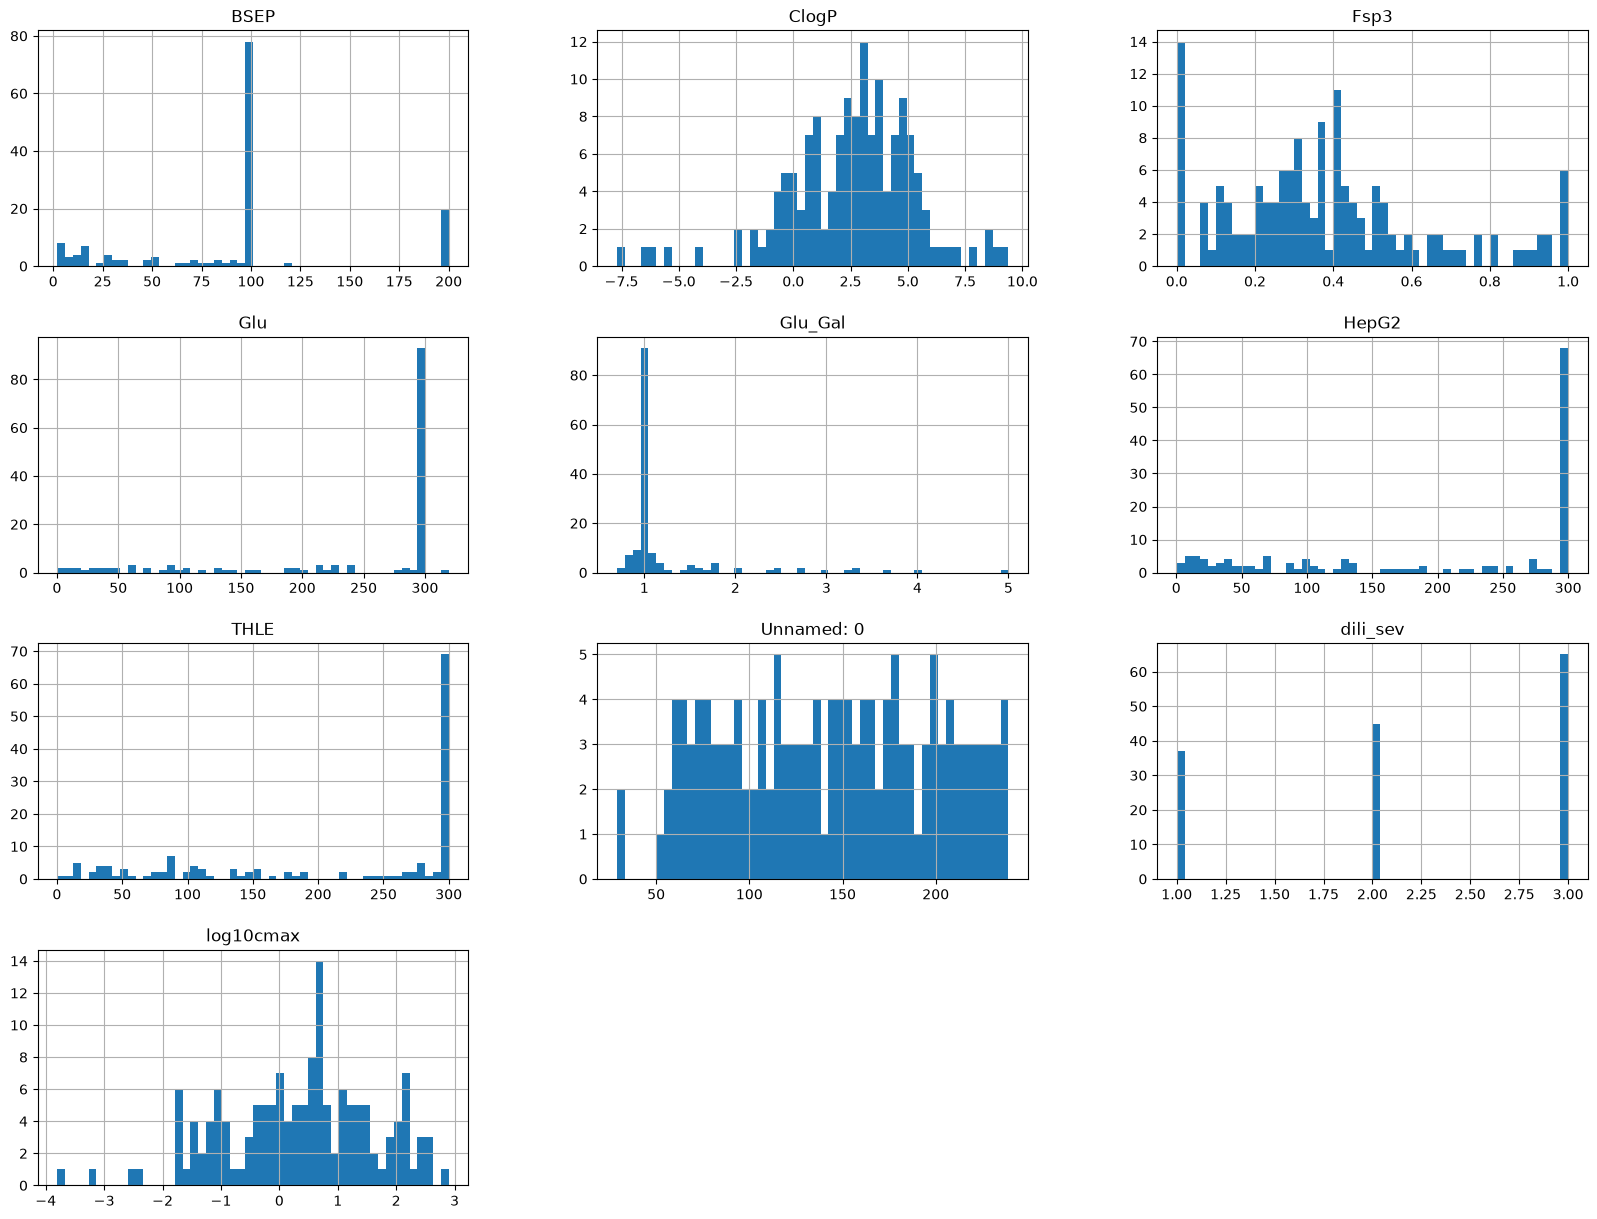

In [6]:
print(training_df[training_df.columns.difference(["vDILIConcern"])].hist(bins=50, figsize=(20,15)))

In [7]:
training_df.corr(numeric_only=True)

,Unnamed: 0,ClogP,BSEP,Glu,Glu_Gal,THLE,HepG2,Fsp3,log10cmax,dili_sev
Unnamed: 0,1.000000,0.024579,0.223057,-0.098557,0.043322,-0.101399,-0.191373,0.084600,-0.259076,-0.366098
ClogP,0.024579,1.000000,-0.243513,-0.384001,0.137940,-0.461235,-0.436492,-0.099077,-0.211907,0.160357
BSEP,0.223057,-0.243513,1.000000,0.099539,-0.295927,0.348209,0.134462,0.164115,-0.184096,-0.431972
Glu,-0.098557,-0.384001,0.099539,1.000000,-0.098917,0.678097,0.842908,0.002783,0.364574,0.017383
Glu_Gal,0.043322,0.137940,-0.295927,-0.098917,1.000000,-0.343994,-0.309992,-0.108822,0.065108,0.254834
THLE,-0.101399,-0.461235,0.348209,0.678097,-0.343994,1.000000,0.744584,0.080070,0.287537,-0.166779
HepG2,-0.191373,-0.436492,0.134462,0.842908,-0.309992,0.744584,1.000000,0.058627,0.429015,0.020589
Fsp3,0.084600,-0.099077,0.164115,0.002783,-0.108822,0.080070,0.058627,1.000000,-0.199449,-0.291179
log10cmax,-0.259076,-0.211907,-0.184096,0.364574,0.065108,0.287537,0.429015,-0.199449,1.000000,0.441756
dili_sev,-0.366098,0.160357,-0.431972,0.017383,0.254834,-0.166779,0.020589,-0.291179,0.441756,1.000000


<Axes: >

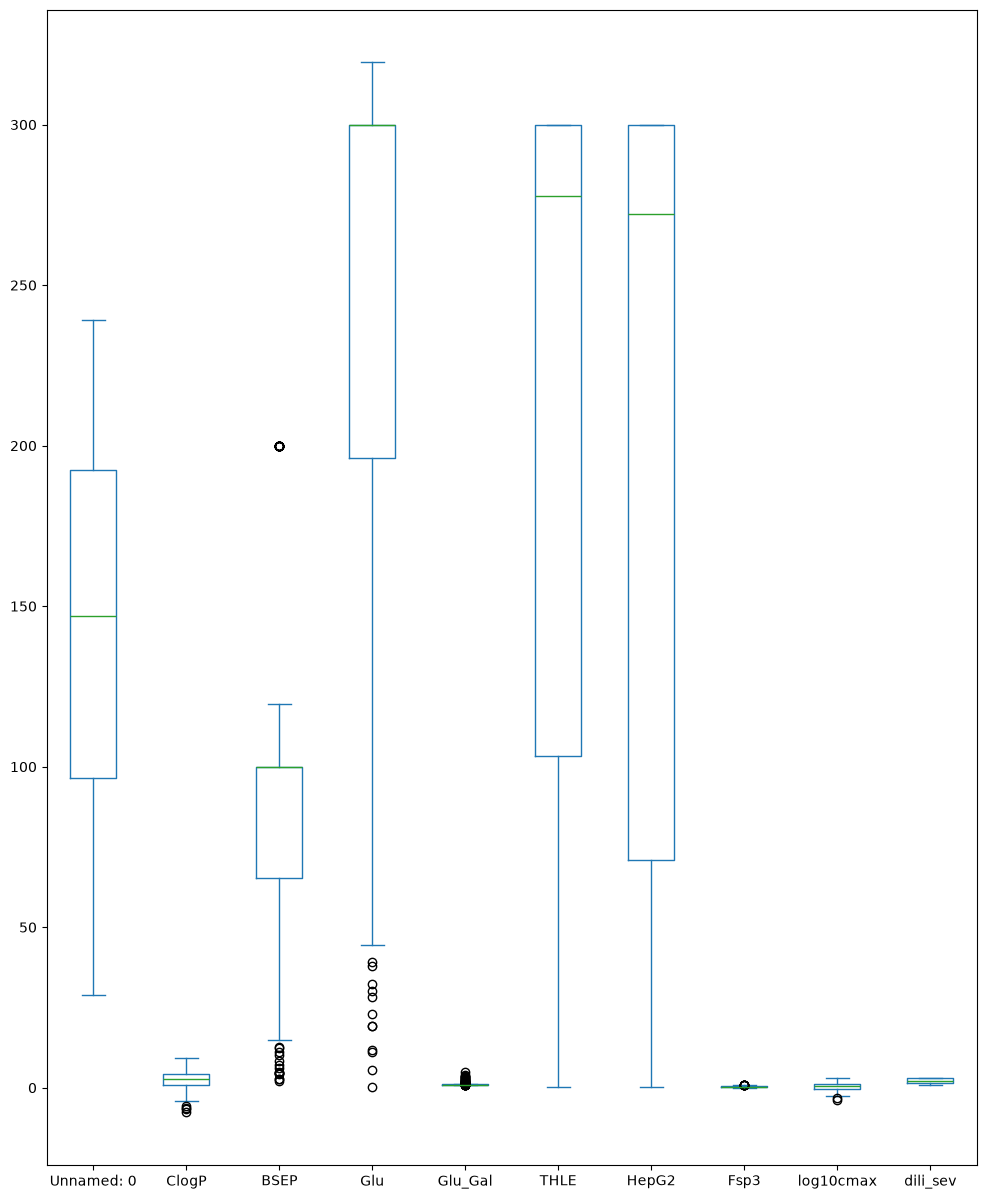

In [8]:
training_df.plot.box(figsize=(12,15))

In [9]:
# Test Data 
print(testing_df.head())

   Unnamed: 0          Drug  ClogP     BSEP      Glu  Glu_Gal     THLE  \
0          70  Clotrimazole  5.004   14.546  103.481      1.4   42.018   
1          72  Deferoxamine -0.184  100.000  300.000      1.0   80.554   
2          82     Ketorolac  1.622  100.000   97.635      0.7  298.884   
3          85    Metoprolol  1.486  100.000  300.000      1.0  300.000   
4          89    Nifedipine  3.125   52.173  173.898      1.4   71.358   

     HepG2       vDILIConcern   Fsp3  log10cmax  dili_sev  
0   58.691  Less-DILI-Concern  0.045  -1.060481         2  
1   14.333  Less-DILI-Concern  0.800   1.251273         2  
2  158.300  Less-DILI-Concern  0.200   0.547775         2  
3  300.000  Less-DILI-Concern  0.600  -0.008774         2  
4   75.598  Less-DILI-Concern  0.294  -0.567031         2  


In [10]:
print(testing_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    37 non-null     int64  
 1   Drug          37 non-null     object 
 2   ClogP         37 non-null     float64
 3   BSEP          37 non-null     float64
 4   Glu           37 non-null     float64
 5   Glu_Gal       37 non-null     float64
 6   THLE          37 non-null     float64
 7   HepG2         37 non-null     float64
 8   vDILIConcern  37 non-null     object 
 9   Fsp3          37 non-null     float64
 10  log10cmax     37 non-null     float64
 11  dili_sev      37 non-null     int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 3.6+ KB
None


In [11]:
print(training_df.describe())

       Unnamed: 0       ClogP        BSEP         Glu     Glu_Gal        THLE  \
count  147.000000  147.000000  147.000000  147.000000  147.000000  147.000000   
mean   144.455782    2.540279   92.628116  237.920490    1.233333  209.784190   
std     55.199790    2.826159   54.574298   98.440635    0.659528  107.107374   
min     29.000000   -7.696000    2.055000    0.293000    0.700000    0.301000   
25%     96.500000    0.886000   65.184500  196.004500    1.000000  103.335500   
50%    147.000000    2.816000  100.000000  300.000000    1.000000  277.700000   
75%    192.500000    4.394000  100.000000  300.000000    1.100000  300.000000   
max    239.000000    9.391000  200.000000  319.375000    5.000000  300.000000   

            HepG2        Fsp3   log10cmax    dili_sev  
count  147.000000  147.000000  147.000000  147.000000  
mean   195.497483    0.381605    0.348875    2.190476  
std    116.076745    0.261273    1.278020    0.813696  
min      0.358000    0.000000   -3.802110    1

In [12]:
print(testing_df['dili_sev'].value_counts())

dili_sev
3    16
2    11
1    10
Name: count, dtype: int64


[[<Axes: title={'center': 'BSEP'}> <Axes: title={'center': 'ClogP'}>
  <Axes: title={'center': 'Fsp3'}>]
 [<Axes: title={'center': 'Glu'}> <Axes: title={'center': 'Glu_Gal'}>
  <Axes: title={'center': 'HepG2'}>]
 [<Axes: title={'center': 'THLE'}> <Axes: title={'center': 'Unnamed: 0'}>
  <Axes: title={'center': 'dili_sev'}>]
 [<Axes: title={'center': 'log10cmax'}> <Axes: > <Axes: >]]


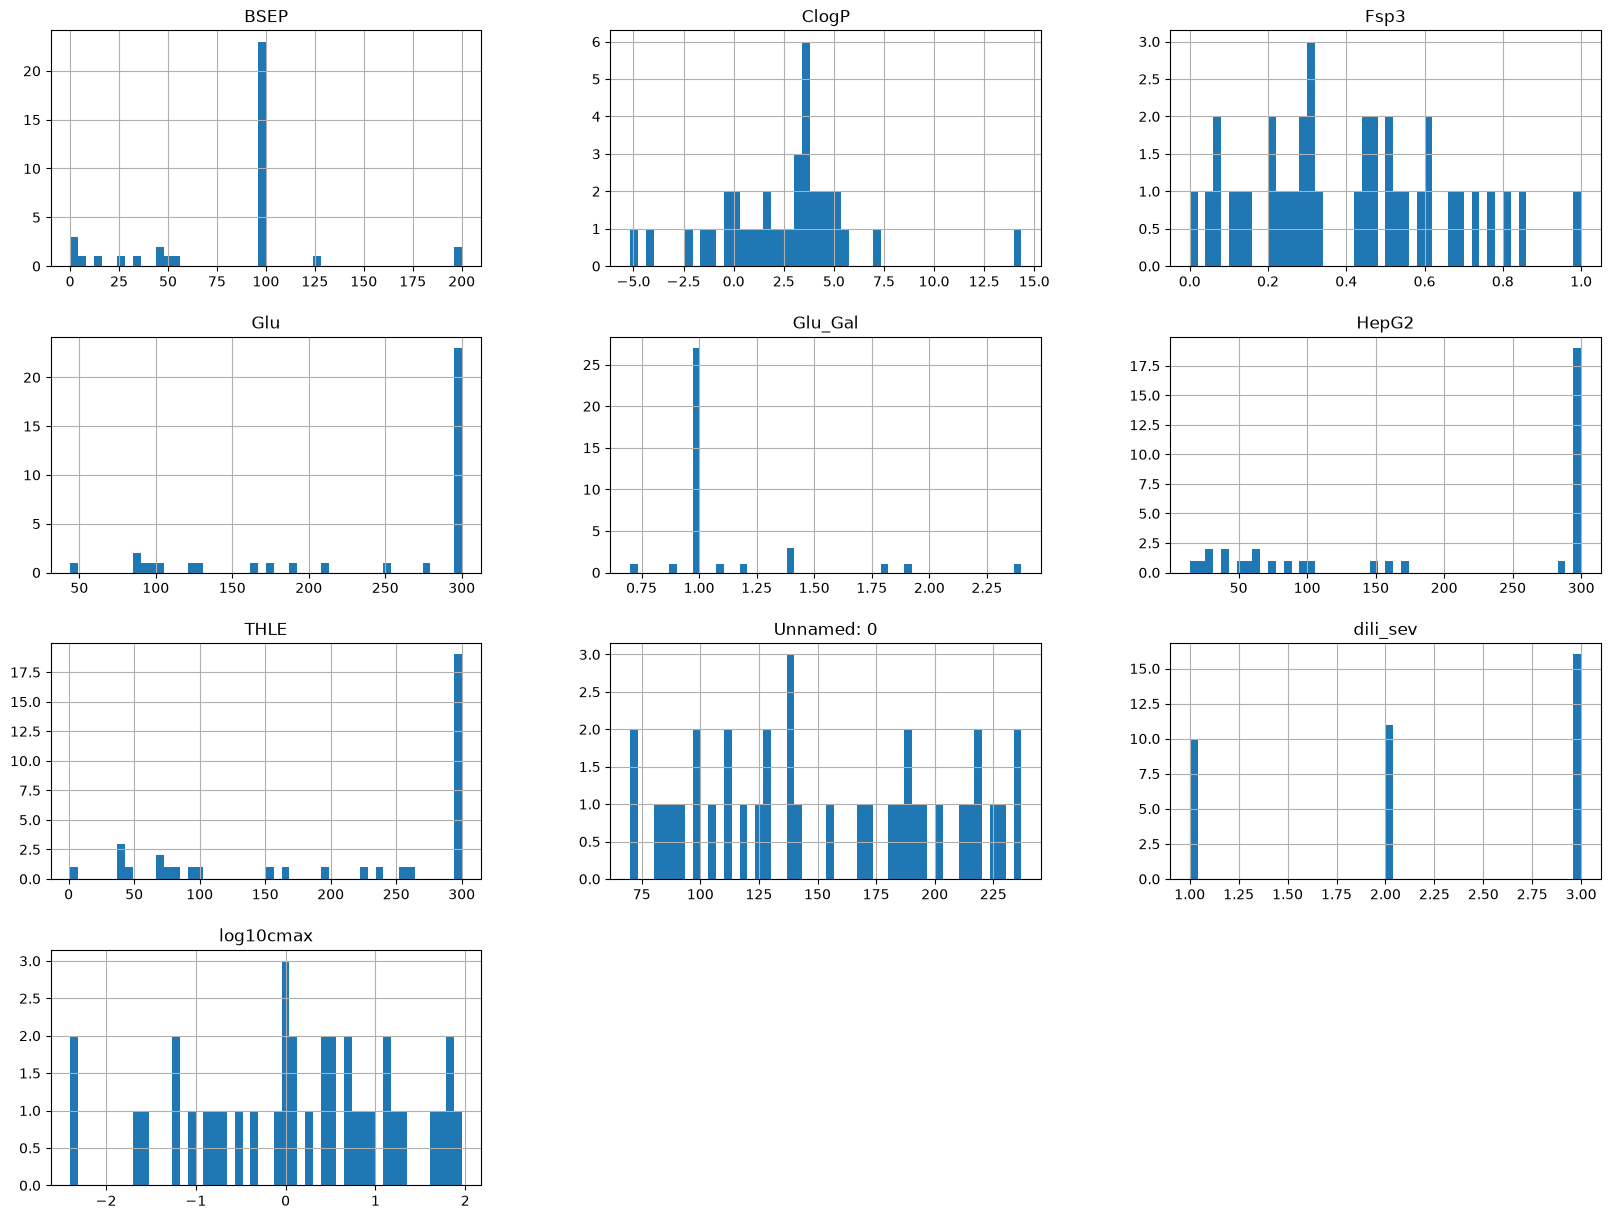

In [13]:
print(testing_df[testing_df.columns.difference(["vDILIConcern"])].hist(bins=50, figsize=(20,15)))

In [14]:
testing_df.corr(numeric_only=True)

,Unnamed: 0,ClogP,BSEP,Glu,Glu_Gal,THLE,HepG2,Fsp3,log10cmax,dili_sev
Unnamed: 0,1.000000,-0.199178,0.393181,0.154686,0.062582,0.234811,0.256359,0.330306,-0.139759,-0.394666
ClogP,-0.199178,1.000000,-0.428086,-0.362051,0.141414,-0.570401,-0.446587,-0.426895,-0.213307,0.262214
BSEP,0.393181,-0.428086,1.000000,0.284732,-0.172840,0.576318,0.382115,0.277159,-0.128507,-0.411416
Glu,0.154686,-0.362051,0.284732,1.000000,-0.211484,0.687506,0.758803,0.023639,0.372430,0.210676
Glu_Gal,0.062582,0.141414,-0.172840,-0.211484,1.000000,-0.455034,-0.452853,-0.281146,-0.034577,0.002003
THLE,0.234811,-0.570401,0.576318,0.687506,-0.455034,1.000000,0.886081,0.103334,0.255732,-0.033976
HepG2,0.256359,-0.446587,0.382115,0.758803,-0.452853,0.886081,1.000000,0.064845,0.245744,0.009304
Fsp3,0.330306,-0.426895,0.277159,0.023639,-0.281146,0.103334,0.064845,1.000000,-0.002251,-0.436840
log10cmax,-0.139759,-0.213307,-0.128507,0.372430,-0.034577,0.255732,0.245744,-0.002251,1.000000,0.467461
dili_sev,-0.394666,0.262214,-0.411416,0.210676,0.002003,-0.033976,0.009304,-0.436840,0.467461,1.000000


<Axes: >

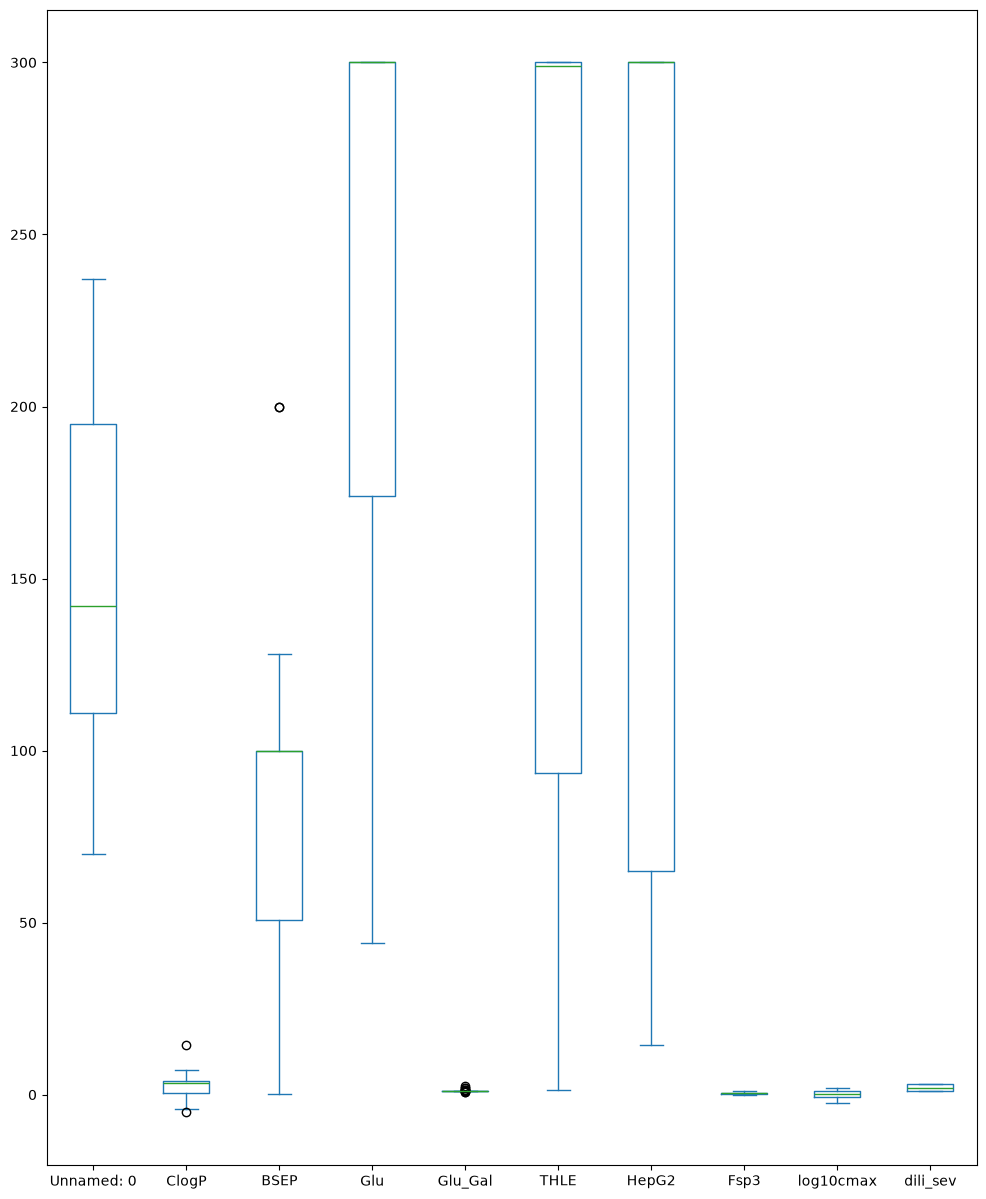

In [15]:
testing_df.plot.box(figsize=(12,15))